In [1]:
%pip install tensorflow==2.20.0 scikit-learn seaborn matplotlib pandas numpy sastrawi nltk wordcloud

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import datetime as dt
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')  # Kompatibel untuk NLTK versi baru yang membutuhkan resource punkt_tab.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("TensorFlow version:", tf.__version__)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


TensorFlow version: 2.20.0


[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
DATA_PATH = Path("content/reviews_hok.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "File /content/reviews_hok.csv belum ditemukan. Jalankan notebook scrapping.ipynb terlebih dahulu."
    )

df = pd.read_csv(DATA_PATH)
print("Shape data awal:", df.shape)
df.head()

Shape data awal: (12000, 9)


,review_id,app_id,app_name,user_name,score,content,thumbs_up,at,app_version
0,2c793cc6-a533-4756-899c-929fe0905f1f,com.levelinfinite.sgameGlobal,Honor of King,Muhammad Ramadani,5,"game nya seru, developer nya baik, heronya balance daripada moba lain. hal yang aku permasalahkan; sering kali layar...",11,2026-04-03 14:50:36,11.3.1.8
1,03d587fa-daa9-4a40-b7c0-31ad6207ec45,com.levelinfinite.sgameGlobal,Honor of King,Andriyanto,2,"tolong perbaiki peforma peningkatan sinyal nya, kadang yang diutamakan itu pengalaman bermain, tolong perbaiki serve...",2,2026-04-23 17:57:13,11.3.1.9
2,f9f2926a-cfd2-4c77-b668-48813c845d28,com.levelinfinite.sgameGlobal,Honor of King,Andika,2,"gamenya udah bagus cuma ada kekurangan di fitur download, yaitu skin dalam match (yang dimiliki) sama yang (belum di...",1,2026-04-25 07:25:37,11.3.1.9
3,6febf65b-1bcd-4893-879a-03b7679ea16c,com.levelinfinite.sgameGlobal,Honor of King,icooo,1,"game rusak game rusak, lain kali kalo update jangan cuma mikirin skin,collab,dll. pentingin juga optimalisasi jaring...",0,2026-04-27 08:59:50,11.3.1.9
4,7a0f84f8-5c43-497a-b6c2-35b045d29061,com.levelinfinite.sgameGlobal,Honor of King,Nur Juminati,5,"Suka banget sama game nya, soalnya hero nya juga kebanyakan cakep-cakep:b. Cuma ya.. Kekurangan nya itu cuma satu, j...",1,2026-04-24 00:44:56,11.3.1.9


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    12000 non-null  str  
 1   app_id       12000 non-null  str  
 2   app_name     12000 non-null  str  
 3   user_name    12000 non-null  str  
 4   score        12000 non-null  int64
 5   content      12000 non-null  str  
 6   thumbs_up    12000 non-null  int64
 7   at           12000 non-null  str  
 8   app_version  9008 non-null   str  
dtypes: int64(2), str(7)
memory usage: 843.9 KB


In [15]:
clean_df = df.dropna()
clean_df = clean_df.drop_duplicates()

clean_df.info()

<class 'pandas.DataFrame'>
Index: 9008 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    9008 non-null   str  
 1   app_id       9008 non-null   str  
 2   app_name     9008 non-null   str  
 3   user_name    9008 non-null   str  
 4   score        9008 non-null   int64
 5   content      9008 non-null   str  
 6   thumbs_up    9008 non-null   int64
 7   at           9008 non-null   str  
 8   app_version  9008 non-null   str  
dtypes: int64(2), str(7)
memory usage: 703.8 KB


In [16]:
display(clean_df["score"].value_counts().sort_index())

score
1    2936
2     869
3     979
4    1088
5    3136
Name: count, dtype: int64

In [ ]:
clean_df = clean_df.copy()
clean_df["sentiment_seed"] = clean_df["score"].astype(int).map(
    lambda score: "negative" if score <= 2 else ("neutral" if score == 3 else "positive")
)

print("Distribusi score:")
display(clean_df["score"].value_counts().sort_index())

print("Total data untuk training:", len(clean_df))


Distribusi score:


score
1    2936
2     869
3     979
4    1088
5    3136
Name: count, dtype: int64

Total data untuk training: 9008


In [19]:
slangwords = {
    "@": "di", 
    "abis": "habis", 
    "wtb": "beli", 
    "masi": "masih", 
    "wts": "jual", 
    "wtt": "tukar", 
    "bgt": "banget", 
    "maks": "maksimal",
    
    # umum / intensifier
    "bgtt": "banget",
    "bngt": "banget",
    "bgtu": "begitu",
    "parahh": "parah",
    "paraaaah": "parah",
    "bnr": "benar",
    "bener": "benar",
    "sbnrnya": "sebenarnya",
    "sebenernya": "sebenarnya",

    # pengalaman penggunaan
    "lemot": "lambat",
    "ngelag": "lag",
    "lagg": "lag",
    "forceclose": "force close",
    "fc": "force close",
    "crashh": "crash",
    "erro": "error",
    "eror": "error",
    "erorr": "error",
    "bugg": "bug",

    # ekspresi negatif
    "jelek bgt": "sangat jelek",
    "jelekk": "jelek",
    "burikk": "buruk",
    "ampas": "buruk",
    "gajelas": "tidak jelas",
    "ga jelas": "tidak jelas",
    "gk jelas": "tidak jelas",
    "gkguna": "tidak berguna",
    "gk guna": "tidak berguna",
    "nyesel": "menyesal",
    "kapok": "jera",

    # ekspresi positif
    "bagusss": "bagus",
    "baguus": "bagus",
    "mantapp": "mantap",
    "mantaaap": "mantap",
    "kereen": "keren",
    "kerenn": "keren",
    "rekomended": "direkomendasikan",
    "worthit": "sepadan",
    "worth it": "sepadan",

    # kata kerja umum di review
    "gk bisa": "tidak bisa",
    "ga bisa": "tidak bisa",
    "gabisa": "tidak bisa",
    "nggak bisa": "tidak bisa",
    "gk mau": "tidak mau",
    "ga mau": "tidak mau",
    "gabakal": "tidak akan",
    "gk bakal": "tidak akan",

    # login / akun
    "gk masuk": "tidak bisa masuk",
    "ga masuk": "tidak bisa masuk",
    "gabisa login": "tidak bisa login",
    "gk login": "tidak bisa login",

    # update / versi
    "abis update": "setelah update",
    "stlh update": "setelah update",
    "updte": "update",
    "updet": "update",

    # rating emphasis
    "bintang 1": "rating rendah",
    "bintang satu": "rating rendah",
    "bintang 5": "rating tinggi"
};

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

def label_from_score(score: int) -> str:
    if score <= 2:
        return "negative"
    if score == 3:
        return "neutral"
    return "positive"

In [20]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text, preserve_line=True)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [ ]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

Shape setelah preprocessing: (9008, 18)


,score,sentiment,text_clean
0,5,positive,game nya seru developer nya baik heronya balance daripada moba lain hal yang aku permasalahkan sering kali layar mac...
1,2,negative,tolong perbaiki peforma peningkatan sinyal nya kadang yang diutamakan itu pengalaman bermain tolong perbaiki server ...
2,2,negative,gamenya udah bagus cuma ada kekurangan di fitur download yaitu skin dalam match yang dimiliki sama yang belum dimili...
3,1,negative,game rusak game rusak lain kali kalo update jangan cuma mikirin skincollabdll pentingin juga optimalisasi jaringan g...
4,5,positive,Suka banget sama game nya soalnya hero nya juga kebanyakan cakepcakepb Cuma ya Kekurangan nya itu cuma satu jaringan...


In [23]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")
 
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [26]:
# Fungsi untuk menentukan polaritas sentimen dari tweet
 
def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:
 
    score = 0
    # Inisialisasi skor sentimen ke 0
 
    for word in text:
        # Mengulangi setiap kata dalam teks
 
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen
 
    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)
 
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen
 
    polarity=''
    # Inisialisasi variabel polaritas
 
    if (score >= 0 & score < 3):
        polarity = 'negative'
        # Jika skor sentimen lebih besar atau sama dengan 0 dan kurang dari 3, maka polaritas adalah negatif
    elif (score == 3):
        polarity = 'neutral'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah neutral
    else:
        polarity = 'positive'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas positif
 
    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [27]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    5199
negative    3809
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=clean_df,
    x="sentiment",
    order=["negative", "neutral", "positive"],
    palette="Set2",
    hue="sentiment",
    legend=False
  )
ax.set_title("Distribusi Label Sentimen")
ax.set_xlabel("Sentimen")
ax.set_ylabel("Jumlah")
plt.show()

clean_df["sentiment"].value_counts()

In [40]:
# Pakai teks hasil preprocessing lanjutan agar sinyal sentimen lebih bersih
X = balanced_df["text_akhir"].astype(str).to_numpy(dtype=str)
y = balanced_df["label_id"].astype("int32").to_numpy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(classes, class_weights)}

print("Jumlah data:")
print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))
print("Dtype X_train:", X_train.dtype, "| Dtype y_train:", y_train.dtype)
print("Class weights:", class_weight_dict)

Jumlah data:
Train: 91730
Val  : 19656
Test : 19657
Dtype X_train: <U430 | Dtype y_train: int32
Class weights: {0: 0.9999890985599198, 1: 0.9999890985599198, 2: 1.0000218035932322}


In [41]:
MAX_TOKENS = 30000
SEQ_LENGTH = 120
BATCH_SIZE = 64
EPOCHS = 20


def compile_and_train(model, x_train, y_train, x_val, y_val, model_name: str, class_weight=None):
    # Keras pada environment ini lebih stabil jika input teks dipaksa menjadi tensor tf.string
    x_train = tf.constant(np.asarray(x_train), dtype=tf.string)
    y_train = tf.constant(np.asarray(y_train), dtype=tf.int32)
    x_val = tf.constant(np.asarray(x_val), dtype=tf.string)
    y_val = tf.constant(np.asarray(y_val), dtype=tf.int32)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=3, mode="max", restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5
        ),
    ]

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks,
        class_weight=class_weight,
    )

    return history


def evaluate_model(model, x_test, y_test, model_name: str):
    x_test = tf.constant(np.asarray(x_test), dtype=tf.string)
    y_test = np.asarray(y_test, dtype=np.int32)

    pred_probs = model.predict(x_test, verbose=0)
    y_pred = pred_probs.argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print(f"\n[{model_name}] Test Accuracy: {acc:.4f}")
    print(f"[{model_name}] Macro F1     : {macro_f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["negative", "neutral", "positive"]))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "neutral", "positive"],
        yticklabels=["negative", "neutral", "positive"],
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return acc, macro_f1, y_pred

## Eksperimen 1: TF-IDF (TextVectorization) + Dense Neural Network

In [42]:
vectorizer_tfidf = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    ngrams=2,
    output_mode="tf_idf",
)
vectorizer_tfidf.adapt(X_train)

inp = keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer_tfidf(inp)
x = layers.Dense(
    512,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4),
)(x)
x = layers.LayerNormalization()(x)
x = layers.Dropout(0.45)(x)
x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4),
)(x)
x = layers.Dropout(0.35)(x)
out = layers.Dense(3, activation="softmax")(x)

model_1 = keras.Model(inp, out, name="tfidf_bigram_dense")
model_1.summary()

Model: "tfidf_bigram_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 1, 30000)       │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1, 512)         │    15,360,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 1, 512)         │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1, 256)         │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1, 3)           │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,493,635 (59.10 MB)

 Trainable params: 15,493,635 (59.10 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history_1 = compile_and_train(
    model_1,
    X_train,
    y_train,
    X_val,
    y_val,
    "TFIDF + Dense",
    class_weight=class_weight_dict,
)
acc_1, f1_1, pred_1 = evaluate_model(model_1, X_test, y_test, "TFIDF + Dense")

Epoch 1/20
1434/1434 ━━━━━━━━━━━━━━━━━━━━ 431s 299ms/step - accuracy: 0.8231 - loss: 0.5583 - val_accuracy: 0.8888 - val_loss: 0.4136 - learning_rate: 5.0000e-04
Epoch 2/20
 533/1434 ━━━━━━━━━━━━━━━━━━━━ 4:25 294ms/step - accuracy: 0.8979 - loss: 0.3891

KeyboardInterrupt: 

## Eksperimen 2: Sequence Vectorization + Embedding + BiLSTM

In [ ]:
vectorizer_seq = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=SEQ_LENGTH,
)
vectorizer_seq.adapt(X_train)

inp2 = keras.Input(shape=(1,), dtype=tf.string)
x2 = vectorizer_seq(inp2)
x2 = layers.Embedding(input_dim=MAX_TOKENS, output_dim=128, mask_zero=True)(x2)
x2 = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x2)
x2 = layers.Bidirectional(layers.LSTM(32))(x2)
x2 = layers.Dropout(0.35)(x2)
x2 = layers.Dense(64, activation="relu")(x2)
out2 = layers.Dense(3, activation="softmax")(x2)

model_2 = keras.Model(inp2, out2, name="seq_bilstm")
model_2.summary()

Model: "seq_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 120)       │          0 │ input_layer_9[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 120, 128)  │  3,840,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 120)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 120, 128)  │     98,816 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 64)        │     41,216 │ bidirectional_4[… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64)        │          0 │ bidirectional_5[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │      4,160 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 3)         │        195 │ dense_25[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,984,387 (15.20 MB)

 Trainable params: 3,984,387 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 71s 306ms/step - accuracy: 0.6286 - loss: 0.9959 - val_accuracy: 0.8121 - val_loss: 0.9171 - learning_rate: 5.0000e-04
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 59s 294ms/step - accuracy: 0.8806 - loss: 0.8108 - val_accuracy: 0.7934 - val_loss: 0.8394 - learning_rate: 5.0000e-04
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 59s 296ms/step - accuracy: 0.9015 - loss: 0.6372 - val_accuracy: 0.8451 - val_loss: 0.6819 - learning_rate: 5.0000e-04
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 56s 280ms/step - accuracy: 0.9221 - loss: 0.4928 - val_accuracy: 0.8528 - val_loss: 0.6116 - learning_rate: 5.0000e-04
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 57s 284ms/step - accuracy: 0.9303 - loss: 0.3887 - val_accuracy: 0.8554 - val_loss: 0.6245 - learning_rate: 5.0000e-04
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 54s 269ms/step - accuracy: 0.9382 - loss: 0.3131 - val_accuracy: 0.8323 - val_loss: 0.6948 - learning_rate: 5.0000e-04
Epoch 7/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 58s 29

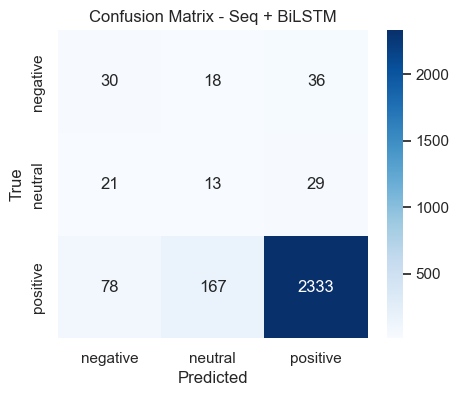

Akurasi Model 1 (TFIDF + Dense): 0.9303 | Macro F1: 0.3932
Akurasi Model 2 (Seq + BiLSTM): 0.8719 | Macro F1: 0.4397


In [ ]:
history_2 = compile_and_train(
    model_2,
    X_train,
    y_train,
    X_val,
    y_val,
    "Seq + BiLSTM",
    class_weight=class_weight_dict,
)
acc_2, f1_2, pred_2 = evaluate_model(model_2, X_test, y_test, "Seq + BiLSTM")

print(f"Akurasi Model 1 (TFIDF + Dense): {acc_1:.4f} | Macro F1: {f1_1:.4f}")
print(f"Akurasi Model 2 (Seq + BiLSTM): {acc_2:.4f} | Macro F1: {f1_2:.4f}")

## Eksperimen 3: Sequence Vectorization + Embedding + CNN

In [ ]:
inp3 = keras.Input(shape=(1,), dtype=tf.string)
x3 = vectorizer_seq(inp3)
x3 = layers.Embedding(input_dim=MAX_TOKENS, output_dim=128)(x3)
x3 = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(x3)
x3 = layers.BatchNormalization()(x3)
x3 = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x3)
x3 = layers.GlobalMaxPooling1D()(x3)
x3 = layers.Dropout(0.30)(x3)
x3 = layers.Dense(64, activation="relu")(x3)
out3 = layers.Dense(3, activation="softmax")(x3)

model_3 = keras.Model(inp3, out3, name="seq_cnn")
model_3.summary()

Model: "seq_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_9            │ (None, 120)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 120, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 120, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 120, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 120, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,951,555 (15.07 MB)

 Trainable params: 3,951,299 (15.07 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.5452 - loss: 1.0856 - val_accuracy: 0.8950 - val_loss: 1.0148 - learning_rate: 5.0000e-04
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - accuracy: 0.7734 - loss: 0.8479 - val_accuracy: 0.9152 - val_loss: 0.8427 - learning_rate: 5.0000e-04
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.8625 - loss: 0.5948 - val_accuracy: 0.8705 - val_loss: 0.5995 - learning_rate: 5.0000e-04
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.8964 - loss: 0.3948 - val_accuracy: 0.9013 - val_loss: 0.3974 - learning_rate: 5.0000e-04
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9124 - loss: 0.2907 - val_accuracy: 0.8774 - val_loss: 0.4334 - learning_rate: 5.0000e-04

[Seq + CNN] Test Accuracy: 0.9196
[Seq + CNN] Macro F1     : 0.5126
              precision    recall  f1-score   support

    negative       0.36      0.49      0.41        84
     neutral       0.13    

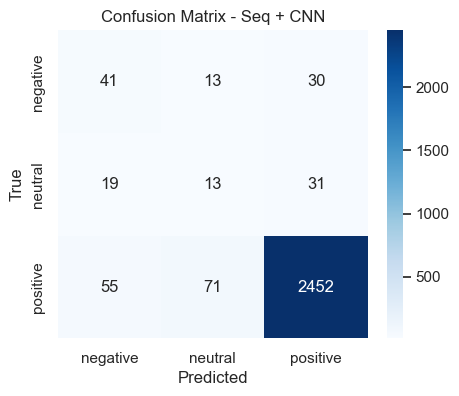

Akurasi Model 1 (TFIDF + Dense): 0.9303 | Macro F1: 0.3932
Akurasi Model 2 (Seq + BiLSTM): 0.8719 | Macro F1: 0.4397
Akurasi Model 3 (Seq + CNN): 0.9196 | Macro F1: 0.5126


In [ ]:
history_3 = compile_and_train(
    model_3,
    X_train,
    y_train,
    X_val,
    y_val,
    "Seq + CNN",
    class_weight=class_weight_dict,
)
acc_3, f1_3, pred_3 = evaluate_model(model_3, X_test, y_test, "Seq + CNN")

print(f"Akurasi Model 1 (TFIDF + Dense): {acc_1:.4f} | Macro F1: {f1_1:.4f}")
print(f"Akurasi Model 2 (Seq + BiLSTM): {acc_2:.4f} | Macro F1: {f1_2:.4f}")
print(f"Akurasi Model 3 (Seq + CNN): {acc_3:.4f} | Macro F1: {f1_3:.4f}")

In [ ]:
print("acc_1 =", round(float(acc_1), 4), "| f1_1 =", round(float(f1_1), 4))
print("acc_2 =", round(float(acc_2), 4), "| f1_2 =", round(float(f1_2), 4))
print("acc_3 =", round(float(acc_3), 4), "| f1_3 =", round(float(f1_3), 4))
print("best_acc =", max(round(float(acc_1), 4), round(float(acc_2), 4), round(float(acc_3), 4)))
print("best_f1  =", max(round(float(f1_1), 4), round(float(f1_2), 4), round(float(f1_3), 4)))

acc_1 = 0.9303 | f1_1 = 0.3932
acc_2 = 0.8719 | f1_2 = 0.4397
acc_3 = 0.9196 | f1_3 = 0.5126
best_acc = 0.9303
best_f1  = 0.5126
